In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import ast
import seaborn as sns
from datasets import load_dataset


# datas = load_dataset('lukebarousse/data_jobs')

# df = datas['train'].to_pandas()
df = pd.read_csv('../data_jobs.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)
countries = ['Denmark','Netherlands','Sweden','Norway','Belgium','Luxemburg','Ireland']
european_countries = [
    # Western Europe
    'Austria', 'Belgium', 'France', 'Germany', 'Liechtenstein', 
    'Luxembourg', 'Monaco', 'Netherlands', 'Switzerland',
    
    # Northern Europe & Nordics / Baltics
    'Denmark', 'Estonia', 'Finland', 'Iceland', 'Ireland', 
    'Latvia', 'Lithuania', 'Norway', 'Sweden', 'United Kingdom',
    
    # Southern Europe
    'Albania', 'Andorra', 'Bosnia and Herzegovina', 'Croatia', 'Cyprus', 
    'Gibraltar', 'Greece', 'Italy', 'Malta', 'Montenegro', 
    'North Macedonia', 'Portugal', 'San Marino', 'Serbia', 'Slovenia', 'Spain',
    
    # Eastern Europe
    'Belarus', 'Bulgaria', 'Czechia', 
    'Czech Republic', 'Georgia', 'Hungary', 
    'Poland', 'Romania', 'Slovakia'
]
jobs = ['Data Engineer','Senior Data Engineer']
dfe = df[df["job_title_short"].isin(jobs)].copy()
dfe = dfe[dfe['job_country'].isin(countries)] #change this accordingly with countries of interest

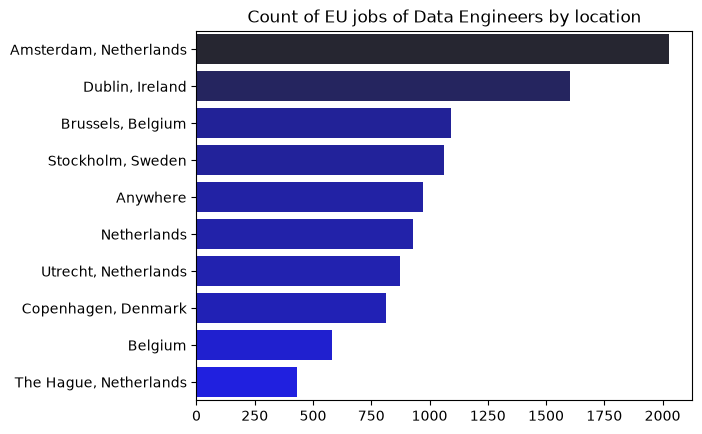

In [14]:
dfc = dfe['job_location'].value_counts().head(10).to_frame()
sns.barplot(data=dfc,x='count',y='job_location',hue='count',palette='dark:b_r',legend=False)
plt.title('Count of EU jobs of Data Engineers by location')
plt.xlabel('')
plt.ylabel('')
# plt.savefig('./images/top_locations.png')
plt.show()

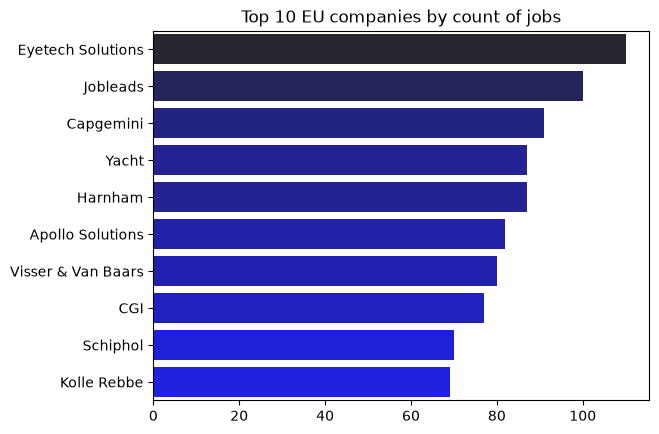

In [15]:
dfcc = dfe['company_name'].value_counts().head(10).to_frame()
sns.barplot(data=dfcc,x='count',y='company_name',hue='count',palette='dark:b_r',legend=False)
plt.title('Top 10 EU companies by count of jobs')
plt.xlabel('')
plt.ylabel('')
# plt.savefig('./images/EU_top_eu_companies.png')
plt.show()